Original Dataset with Missing Values:
    rooms  distance_to_city     price
0     NaN          5.401708  405041.0
1     6.0               NaN  898361.0
2     NaN         13.594154       NaN
3     6.0               NaN       NaN
4     6.0               NaN  848531.0
5     NaN               NaN  451995.0
6     4.0          4.347853  878843.0
7     4.0          8.011472  772843.0
8     4.0          9.792684  456508.0
9     6.0         11.945680  306530.0
10    5.0         19.844223  804365.0
11    4.0          5.792171  660337.0
12    7.0         13.341627  659773.0
13    6.0         15.217950       NaN
14    3.0          2.114810  541097.0
15    5.0         15.581076       NaN
16    7.0          5.092579  371829.0
17    NaN          2.561238  471836.0
18    3.0         23.773253  638974.0
19    5.0         24.175169  402283.0

Rows without missing values:
    rooms  distance_to_city     price
6     4.0          4.347853  878843.0
7     4.0          8.011472  772843.0
8     4.0          9

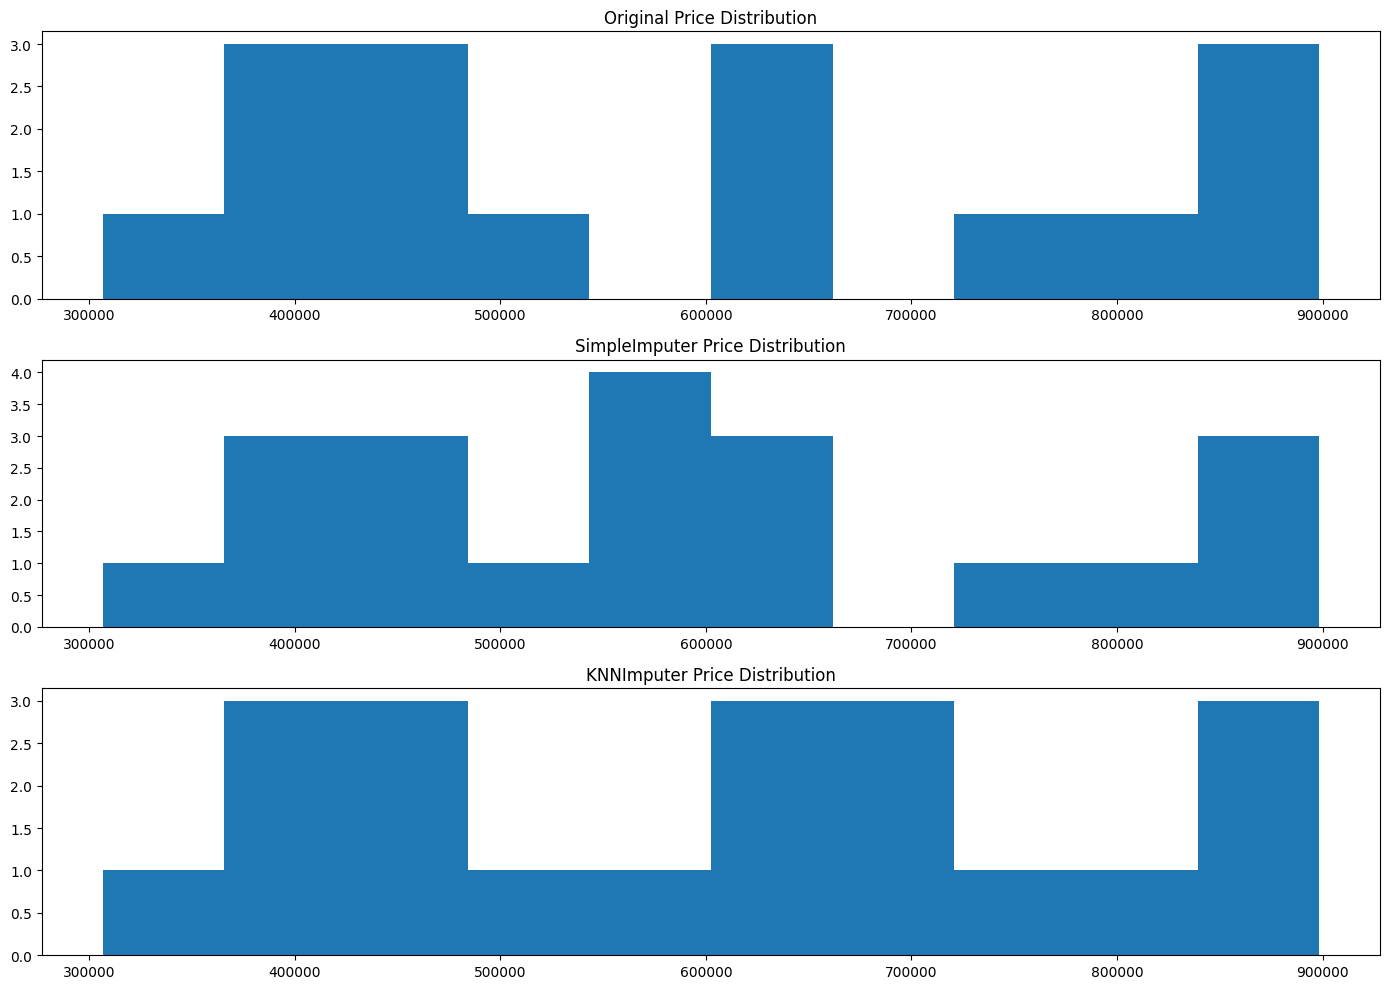


Summary Statistics Comparison:

Original:
          rooms  distance_to_city        price
count  16.00000         16.000000      16.0000
mean    5.06250         11.286728  598071.6250
std     1.28938          7.135310  197742.5324
min     3.00000          2.114810  306530.0000
25%     4.00000          5.324426  440256.5000
50%     5.00000         10.869182  590035.5000
75%     6.00000         15.308731  780723.5000
max     7.00000         24.175169  898361.0000

After SimpleImputer:
           rooms  distance_to_city          price
count  20.000000         20.000000      20.000000
mean    5.050000         11.203219  596464.400000
std     1.145931          6.342205  175729.800154
min     3.000000          2.114810  306530.000000
25%     4.000000          5.694555  455379.750000
50%     5.000000         10.869182  590035.500000
75%     6.000000         14.000103  688463.500000
max     7.000000         24.175169  898361.000000

After KNNImputer:
           rooms  distance_to_city         

In [1]:
# ---------------------------------------------------------
# Project 2: Advanced Imputation with Scikit-Learn
# ---------------------------------------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer, KNNImputer

# ---------------------------------------------------------
# 1. Create Synthetic Dataset (Similar to Housing Data)
# ---------------------------------------------------------
np.random.seed(42)

data = {
    "rooms": np.random.randint(2, 8, 20),
    "distance_to_city": np.random.uniform(1.0, 25.0, 20),
    "price": np.random.randint(200000, 900000, 20)
}

df = pd.DataFrame(data)

# Add random missing values
for col in df.columns:
    df.loc[df.sample(frac=0.2).index, col] = np.nan

print("Original Dataset with Missing Values:")
print(df)

# ---------------------------------------------------------
# 2. Split Data (optional)
# ---------------------------------------------------------
X_missing = df.copy()
X_complete = df.dropna()

print("\nRows without missing values:")
print(X_complete)

# ---------------------------------------------------------
# 3. Imputation using SimpleImputer (Median)
# ---------------------------------------------------------
simple_imputer = SimpleImputer(strategy='median')
simple_imputed = simple_imputer.fit_transform(X_missing)

simple_imputed_df = pd.DataFrame(simple_imputed, columns=df.columns)

print("\nAfter SimpleImputer (Median):")
print(simple_imputed_df)

# ---------------------------------------------------------
# 4. Imputation using KNNImputer
# ---------------------------------------------------------
knn_imputer = KNNImputer(n_neighbors=5)
knn_imputed = knn_imputer.fit_transform(X_missing)

knn_imputed_df = pd.DataFrame(knn_imputed, columns=df.columns)

print("\nAfter KNNImputer:")
print(knn_imputed_df)

# ---------------------------------------------------------
# 5. Compare Distributions (Original vs Simple vs KNN)
# ---------------------------------------------------------
plt.figure(figsize=(14, 10))

plt.subplot(3, 1, 1)
plt.hist(df['price'].dropna(), bins=10)
plt.title("Original Price Distribution")

plt.subplot(3, 1, 2)
plt.hist(simple_imputed_df['price'], bins=10)
plt.title("SimpleImputer Price Distribution")

plt.subplot(3, 1, 3)
plt.hist(knn_imputed_df['price'], bins=10)
plt.title("KNNImputer Price Distribution")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 6. Summary Statistics Comparison
# ---------------------------------------------------------
print("\nSummary Statistics Comparison:")
print("\nOriginal:")
print(df.describe())

print("\nAfter SimpleImputer:")
print(simple_imputed_df.describe())

print("\nAfter KNNImputer:")
print(knn_imputed_df.describe())
